In [14]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

!pip install bertopic
from bertopic import BERTopic

In [3]:
file_path = "/content/corpus.tsv"

df = pd.read_csv(file_path, sep="\t", header=None)
df.columns = ["text", "split", "label"]

df = df.drop(columns=["split"])

# Preview
df.head()

,text,label
0,broadband ahead join internet fast accord offi...,tech
1,plan share sale owner technology dominate inde...,business
2,mobile rack mobile phone celebrate anniversary...,tech
3,launch reconstruction drive appeal peace natio...,business
4,buy giant profit soar acquisition big firm tax...,business


In [4]:
texts = df["text"].astype(str).tolist()
texts

['broadband ahead join internet fast accord official figure number business connect jump report broadband connection end compare nation rank world telecom body election campaign ensure affordable high speed net access american accord report broadband increasingly popular research shopping download music watch video total number business broadband rise end compare hook broadband subscriber line technology ordinary phone line support high data speed cable lead account line broadband phone line connection accord figure',
 'plan share sale owner technology dominate index plan sell share public list market operate accord document file stock market plan raise sale observer step close full public icon technology boom recently pour cold water suggestion company sell share private technically public stock start trade list equity trade money sale investor buy share private filing document share technology firm company high growth potential symbol internet telecom boom bubble burst recovery fortu

In [5]:
topic_model = BERTopic(
    verbose=True,
    calculate_probabilities=True
)

topics, probs = topic_model.fit_transform(texts)

print(topics[:10])

2026-04-20 00:02:30,472 - BERTopic - Embedding - Transforming documents to embeddings.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

2026-04-20 00:05:10,620 - BERTopic - Embedding - Completed ✓
2026-04-20 00:05:10,623 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-20 00:05:33,503 - BERTopic - Dimensionality - Completed ✓
2026-04-20 00:05:33,505 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-20 00:05:34,027 - BERTopic - Cluster - Completed ✓
2026-04-20 00:05:34,036 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-20 00:05:34,478 - BERTopic - Representation - Completed ✓


[23, 7, -1, 3, 7, 0, 10, 0, 6, 22]


In [6]:
len(set(topics))

45

In [7]:
sum(np.array(topics) == -1)

np.int64(513)

In [8]:
df["topic"] = topics
df

,text,label,topic
0,broadband ahead join internet fast accord offi...,tech,23
1,plan share sale owner technology dominate inde...,business,7
2,mobile rack mobile phone celebrate anniversary...,tech,-1
3,launch reconstruction drive appeal peace natio...,business,3
4,buy giant profit soar acquisition big firm tax...,business,7
...,...,...,...
2220,reject terror offer reject conservative compro...,politics,-1
2221,cup history young cup player confirm play doub...,sport,2
2222,leave book accuse oversee fraud accounting dec...,business,8
2223,fight reach final dream australian open title ...,sport,2


In [9]:
topic_to_label = {}

for topic_id in set(topics):
    if topic_id == -1:
        continue

    majority_label = (
        df[df["topic"] == topic_id]["label"]
        .mode()[0]
    )

    topic_to_label[topic_id] = majority_label

print(topic_to_label)

{0: 'entertainment', 1: 'politics', 2: 'sport', 3: 'business', 4: 'tech', 5: 'sport', 6: 'business', 7: 'business', 8: 'business', 9: 'sport', 10: 'sport', 11: 'sport', 12: 'politics', 13: 'business', 14: 'sport', 15: 'sport', 16: 'sport', 17: 'tech', 18: 'politics', 19: 'entertainment', 20: 'tech', 21: 'business', 22: 'tech', 23: 'tech', 24: 'politics', 25: 'tech', 26: 'tech', 27: 'politics', 28: 'business', 29: 'business', 30: 'tech', 31: 'sport', 32: 'politics', 33: 'business', 34: 'business', 35: 'tech', 36: 'business', 37: 'sport', 38: 'politics', 39: 'business', 40: 'tech', 41: 'business', 42: 'tech', 43: 'tech'}


In [10]:
# Each document's predicted label comes from its topic's majority class
df["predicted_label"] = df["topic"].map(topic_to_label)

In [11]:
# Outliers have no predicted label; drop them before evaluation
df_eval = df[df["topic"] != -1].copy()
print(f"Evaluating on {len(df_eval)}/{len(df)} docs ({len(df) - len(df_eval)} outliers excluded)")

Evaluating on 1712/2225 docs (513 outliers excluded)


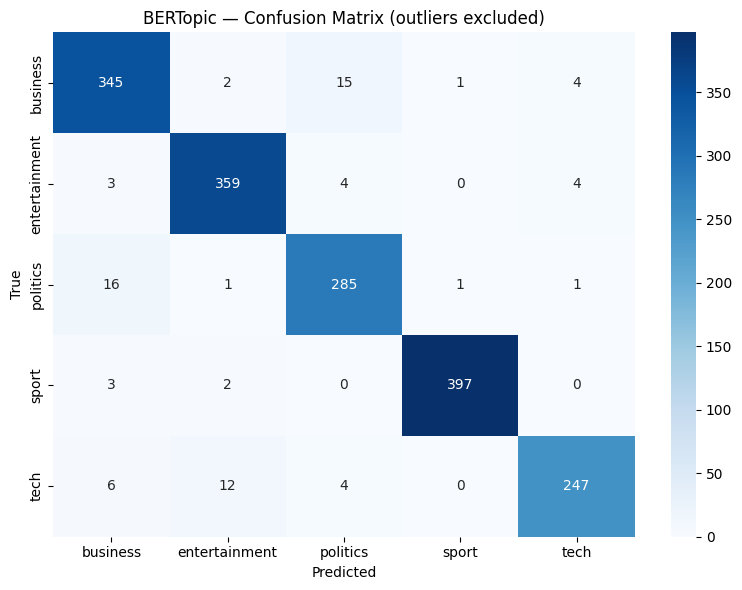

In [13]:
labels = ["business", "entertainment", "politics", "sport", "tech"]

cm = confusion_matrix(df_eval["label"], df_eval["predicted_label"], labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [15]:
print(classification_report(df_eval["label"], df_eval["predicted_label"], labels=labels))

               precision    recall  f1-score   support

     business       0.92      0.94      0.93       367
entertainment       0.95      0.97      0.96       370
     politics       0.93      0.94      0.93       304
        sport       0.99      0.99      0.99       402
         tech       0.96      0.92      0.94       269

     accuracy                           0.95      1712
    macro avg       0.95      0.95      0.95      1712
 weighted avg       0.95      0.95      0.95      1712



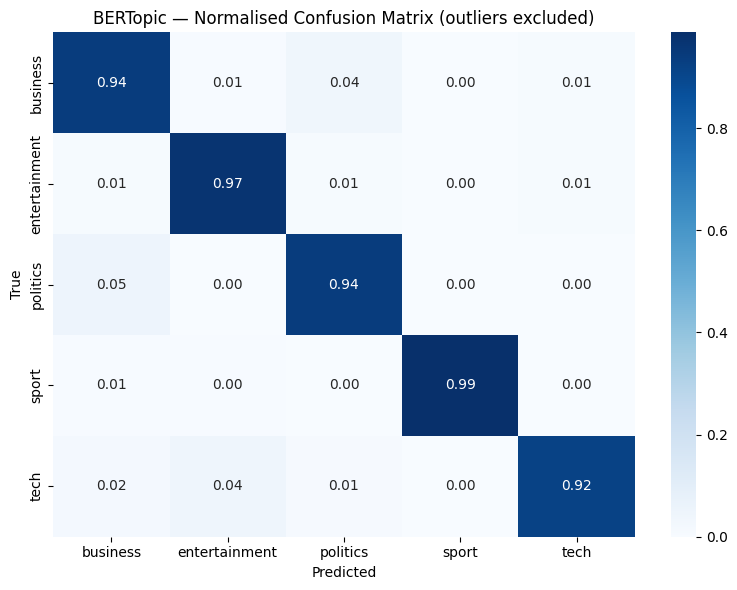

In [17]:
cm_norm = confusion_matrix(df_eval["label"], df_eval["predicted_label"],
                           labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (outliers excluded)")
plt.tight_layout()
plt.show()

In [18]:
coverage = len(df_eval) / len(df)
outlier_breakdown = df[df["topic"] == -1]["label"].value_counts()

print(f"Coverage: {coverage:.1%}")
print("\nOutlier distribution by true label:")
print(outlier_breakdown)

Coverage: 76.9%

Outlier distribution by true label:
label
business         143
tech             132
politics         113
sport            109
entertainment     16
Name: count, dtype: int64


In [19]:
# Total documents per true label
total_per_label = df["label"].value_counts()

# Percentage of each class that became an outlier
outlier_rate = (outlier_breakdown / total_per_label * 100).round(1)

print("Outlier rate by class:")
print(outlier_rate.sort_values(ascending=False))

Outlier rate by class:
label
tech             32.9
business         28.0
politics         27.1
sport            21.3
entertainment     4.1
Name: count, dtype: float64


**Including outliers**

In [21]:
# Reassign outliers to their closest topic using embedding similarity
topics_updated = topic_model.reduce_outliers(documents=texts, topics=topics, strategy="embeddings")

remaining_outliers = sum(t == -1 for t in topics_updated)
print(f"Outliers before: {sum(t == -1 for t in topics)}")
print(f"Outliers after:  {remaining_outliers}")

Outliers before: 513
Outliers after:  0


In [22]:
# Replace the topic column with the updated assignments
df["topic_updated"] = topics_updated
df["predicted_label_updated"] = df["topic_updated"].map(topic_to_label)

In [23]:
df

,text,label,topic,predicted_label,topic_updated,predicted_label_updated
0,broadband ahead join internet fast accord offi...,tech,23,tech,23,tech
1,plan share sale owner technology dominate inde...,business,7,business,7,business
2,mobile rack mobile phone celebrate anniversary...,tech,-1,NaN,23,tech
3,launch reconstruction drive appeal peace natio...,business,3,business,3,business
4,buy giant profit soar acquisition big firm tax...,business,7,business,7,business
...,...,...,...,...,...,...
2220,reject terror offer reject conservative compro...,politics,-1,NaN,18,politics
2221,cup history young cup player confirm play doub...,sport,2,sport,2,sport
2222,leave book accuse oversee fraud accounting dec...,business,8,business,8,business
2223,fight reach final dream australian open title ...,sport,2,sport,2,sport


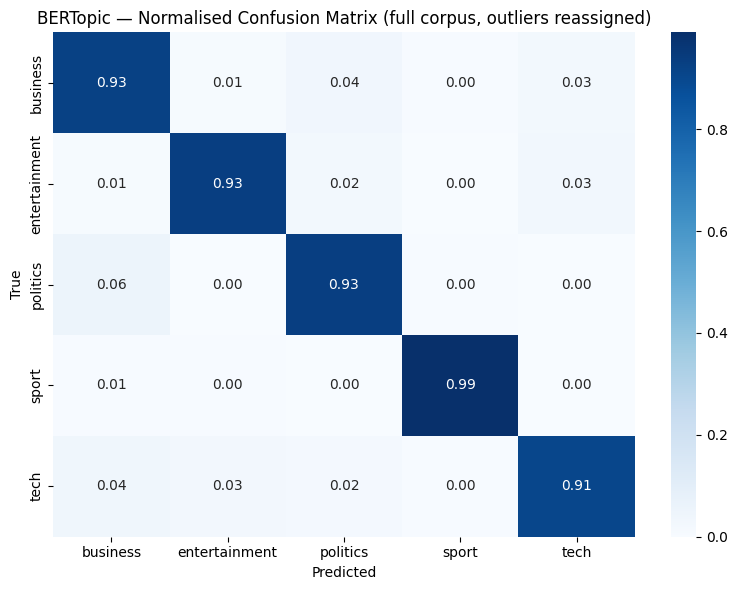

In [24]:
# Now evaluate on the entire corpus
cm_full = confusion_matrix(df["label"], df["predicted_label_updated"],
                           labels=labels, normalize="true")

plt.figure(figsize=(8, 6))
sns.heatmap(cm_full, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("BERTopic — Normalised Confusion Matrix (full corpus, outliers reassigned)")
plt.tight_layout()
plt.show()

In [25]:
print(classification_report(df["label"], df["predicted_label_updated"], labels=labels))

               precision    recall  f1-score   support

     business       0.91      0.93      0.92       510
entertainment       0.95      0.93      0.94       386
     politics       0.92      0.93      0.92       417
        sport       0.99      0.99      0.99       511
         tech       0.93      0.91      0.92       401

     accuracy                           0.94      2225
    macro avg       0.94      0.94      0.94      2225
 weighted avg       0.94      0.94      0.94      2225



In [26]:
summary = {
    "Evaluated docs": [1712, 2225],
    "Coverage": ["76.9%", "100%"],
    "Accuracy": ["95%", "94%"],
    "Macro F1": ["0.95", "0.94"],
}

import pandas as pd
summary_df = pd.DataFrame(summary, index=["Outliers excluded", "Outliers reassigned"])
print(summary_df)

                     Evaluated docs Coverage Accuracy Macro F1
Outliers excluded              1712    76.9%      95%     0.95
Outliers reassigned            2225     100%      94%     0.94
